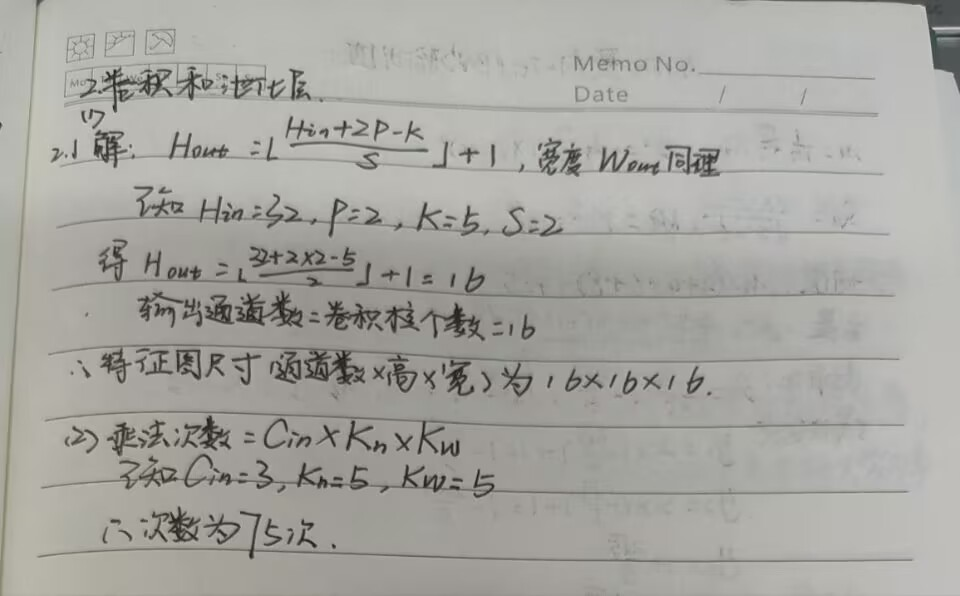
2.卷积和池化层
不使用深度学习框架的底层 Pooling API（如 ‘torch.nn.MaxPool2d‘），
仅使用 Python 和 NumPy（或 PyTorch 基础张量操作），手动实现一个支
持步幅（stride）和填充（padding）的二维最大池化（Max Pooling）前向
传播函数。


2.2 手动实现 MaxPool2d
原理：最大池化是下采样操作，在输入特征图上滑动一个窗口，取窗口内的最大值作为输出。

输出尺寸公式（与卷积相同）：
H_out = floor((H_in + 2*padding - kernel_size) / stride) + 1

核心计算：对于输出位置 (i,j)，对应的输入窗口范围：
h_start = i * stride, h_end = h_start + kernel_size
w_start = j * stride, w_end = w_start + kernel_size
取该窗口内的最大值：out[i,j] = max(input[h_start:h_end, w_start:w_end])

In [1]:
import numpy as np

def max_pool2d_forward(x,kernel_size,stride=None,padding=0):
    """ 
    x: 输入数据(N, C, H, W)
    kernel_size: 池化窗口大小
    stride:步长
    padding:填充
    """
    # 输入尺寸，批量大小，通道数，输入高宽
    N,C,H,W=x.shape

    # 窗口高宽，如果是整数如3，则高宽相同；否则如果是元组（3，5）则分别指定高宽
    if isinstance(kernel_size,int):
        kh=kw=kernel_size
    else:
        kh,kw=kernel_size

    # 步长，如果是整数如2，则高宽相同；否则如果是元组（2，3）则分别指定高宽
    if stride is None:
        sh=sw=kh
    else:
        sh, sw=stride if isinstance(stride,tuple) else (stride,stride)

    # 填充大小,
    ph=pw=padding if isinstance(padding,int) else padding[0]

    # 先填充一圈0,再滑窗取最大值
    x_pad=np.pad(x, ((0,0),(0,0),(ph,ph),(pw,pw)), mode='constant')

    # 输出高宽
    H_out=(H+2*ph-kh) // sh + 1
    W_out=(W+2*pw-kw) // sw + 1

    out=np.zeros((N,C,H_out, W_out))

    # 滑窗取最大值
    for i in range(H_out):
        for j in range(W_out):
            h_start=i*sh
            h_end=h_start+kh
            w_start=j*sw
            w_end=w_start+kw
            window=x_pad[:,:,h_start:h_end,w_start:w_end]
            out[:,:,i,j] = np.max(window,axis=(2,3))
    return out

# 简单测一下
if __name__ == "__main__":
    x=np.random.randn(2,3,32,32)
    out=max_pool2d_forward(x,kernel_size=3,stride=2,padding=1)
    print("输出尺寸:",out.shape)  #  (2,3,16,16)
    
    

输出尺寸: (2, 3, 16, 16)


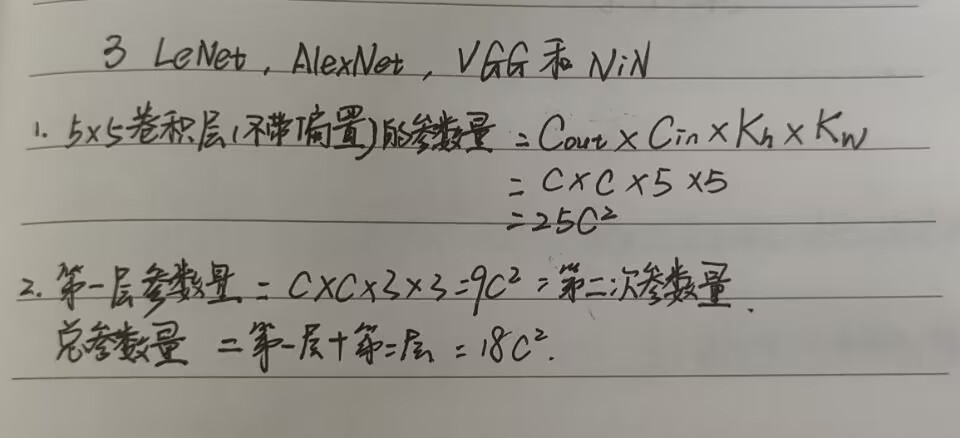
3.2 NiN 块定义
原理：NiN 块使用 1x1 卷积代替全连接层，通过跨通道的信息组合增强非线性，同时减少参数量。

核心操作序列：

普通卷积：out = ReLU(Conv2d(x))
参数量 = C_in * C_out * K_h * K_w
第一个 1x1 卷积：out = ReLU(Conv2d_{1x1}(·))
参数量 = C_out * C_out * 1 * 1 = C_out^2
第二个 1x1 卷积：同理，参数量也是 C_out^2
公式本质：1x1 卷积等价于对每个像素位置在通道维度上做一个全连接层，数学上为：
out_{n,c,i,j} = sum_{c'} (W_{c,c'} * x_{n,c',i,j}) + b_c


In [2]:
import torch
import torch.nn as nn

class NiNBlock(nn.Module):
    """NiN块：一个普通卷积 + 两个1x1卷积，每个后面都跟ReLU"""
    def __init__(self,in_channels,out_channels,kernel_size,stride,padding):
        super(NiNBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels,out_channels,kernel_size, stride, padding),
            nn.ReLU(),
            nn.Conv2d(out_channels,out_channels,kernel_size=1),  # 1x1卷积降维或升维
            nn.ReLU(),
            nn.Conv2d(out_channels,out_channels,kernel_size=1),
            nn.ReLU()
        )

    def forward(self, x):
        return self.block(x)

# 跑一下看看形状
if __name__ == "__main__":
    blk = NiNBlock(3,96,5,1,2)
    x = torch.randn(1,3,224,224)
    y = blk(x)
    print(y.shape)  # (1,96,224,224)

torch.Size([1, 96, 224, 224])


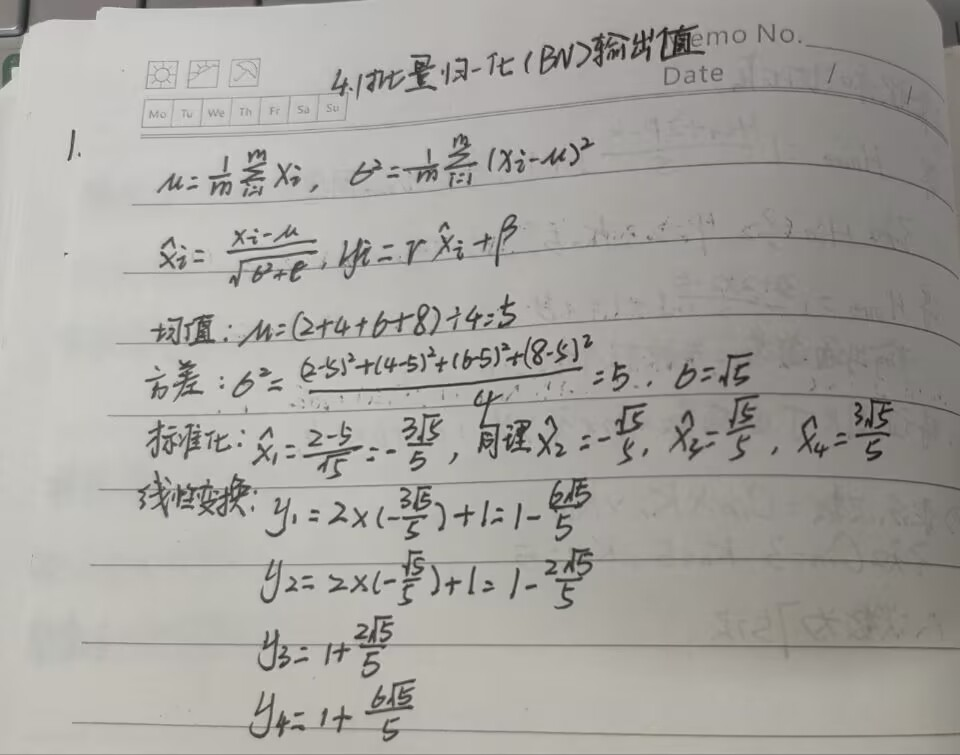
4.2 残差块 Residual
原理：残差学习，让网络学习映射 f(x) 与输入 x 的差值，最后输出 f(x) + x。梯度可以直接沿着捷径传播。

前向公式：
out = ReLU( BN( Conv2_2( ReLU( BN( Conv2_1(x) ) ) ) ) + shortcut(x) )

shortcut 处理：

若 use_1x1conv=False 且 stride=1 且输入输出通道相同：shortcut(x) = x

否则：shortcut(x) = Conv2d_{1x1}(x)，用于调整通道数和尺寸。

In [3]:
import torch
import torch.nn as nn

class Residual(nn.Module):
    """残差块，带BN和可选的1x1捷径"""
    def __init__(self, in_channels,out_channels,use_1x1conv=False, stride=1):
        super(Residual, self).__init__()
        # 第一个卷积，可能改变尺寸（stride>1）
        self.conv1=nn.Conv2d(in_channels,out_channels,kernel_size=3,
                               stride=stride, padding=1)
        self.bn1=nn.BatchNorm2d(out_channels)
        # 第二个卷积，不改变尺寸
        self.conv2=nn.Conv2d(out_channels,out_channels,kernel_size=3,
                               stride=1, padding=1)
        self.bn2=nn.BatchNorm2d(out_channels)

        # 如果输入输出尺寸或通道数不一致，用1x1卷积调整
        if use_1x1conv:
            self.shortcut = nn.Conv2d(in_channels,out_channels,kernel_size=1,
                                      stride=stride)
        else:
            self.shortcut = nn.Identity()  # 什么也不做

    def forward(self, x):
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        # 加上捷径（残差连接）
        out += self.shortcut(x)
        out = torch.relu(out)
        return out

# 测试
if __name__ == "__main__":
    blk = Residual(3, 64, use_1x1conv=True, stride=2)
    #1张图片，3个通道，32x32的输入，经过stride=2的卷积后输出16x16，通道数变为64
    #224+4
    x = torch.randn(1, 3, 32, 32)
    print(blk(x).shape)  # (1,64,16,16)

torch.Size([1, 64, 16, 16])


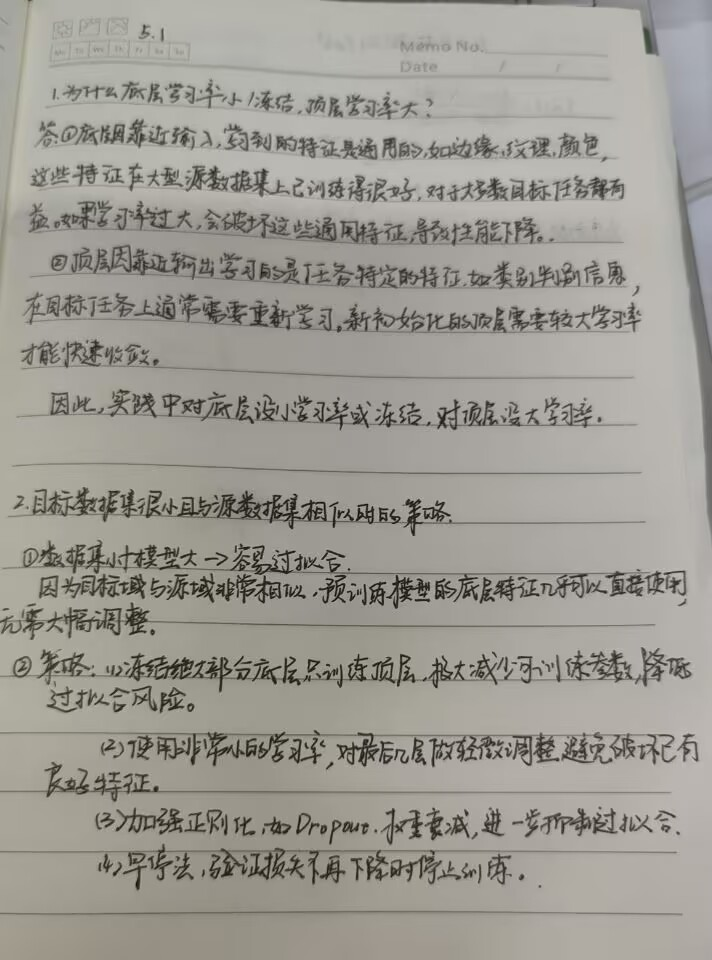
### 5.2 图像增广管道

**原理**：随机数据增强，不改变标签，增加样本多样性。

- **随机裁剪并缩放**：`RandomResizedCrop` 先随机裁剪图像的一块区域（面积比例在 [0.08, 1.0] 之间），然后将该区域缩放到固定尺寸 224×224。裁剪区域的宽高比随机在一定范围内（默认 [3/4, 4/3]）。
- **水平翻转**：以 50% 的概率对图像左右镜像。数学上：若 \(p < 0.5\)，则 \(x_{\text{new}} = W - 1 - x_{\text{old}}\)。
- **颜色抖动**：`ColorJitter` 分别对亮度、对比度、饱和度乘上一个在 \([1-0.5, 1+0.5] = [0.5, 1.5]\) 内均匀采样的因子。
- **转张量**：将 PIL 图像或 NumPy 数组转换为 PyTorch 张量，像素值从 [0,255] 缩放到 [0.0, 1.0]。

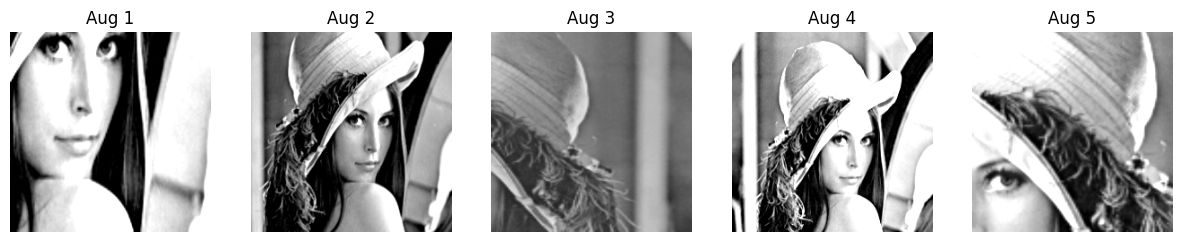

In [4]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt

bmp_img_path = r".\lena.BMP"
img = Image.open(bmp_img_path).convert('RGB')  # 转成RGB三通道
# 把这些增广操作串起来
aug_pipe = transforms.Compose([
    # 随机裁剪再缩放到224，面积比例0.08~1.0
    transforms.RandomResizedCrop(224,scale=(0.08,1.0)),
    # 一半概率水平翻转
    transforms.RandomHorizontalFlip(p=0.5),
    # 随机调亮度、对比度、饱和度，变化幅度0.5
    transforms.ColorJitter(brightness=0.5,contrast=0.5, saturation=0.5),
    # 最后转成Tensor
    transforms.ToTensor()
])

# 生成 5 张不同的增广结果
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    aug_tensor = aug_pipe(img)          # 每次随机
    aug_img = transforms.ToPILImage()(aug_tensor)
    axes[i].imshow(aug_img)
    axes[i].axis('off')
    axes[i].set_title(f'Aug {i+1}')
plt.show()





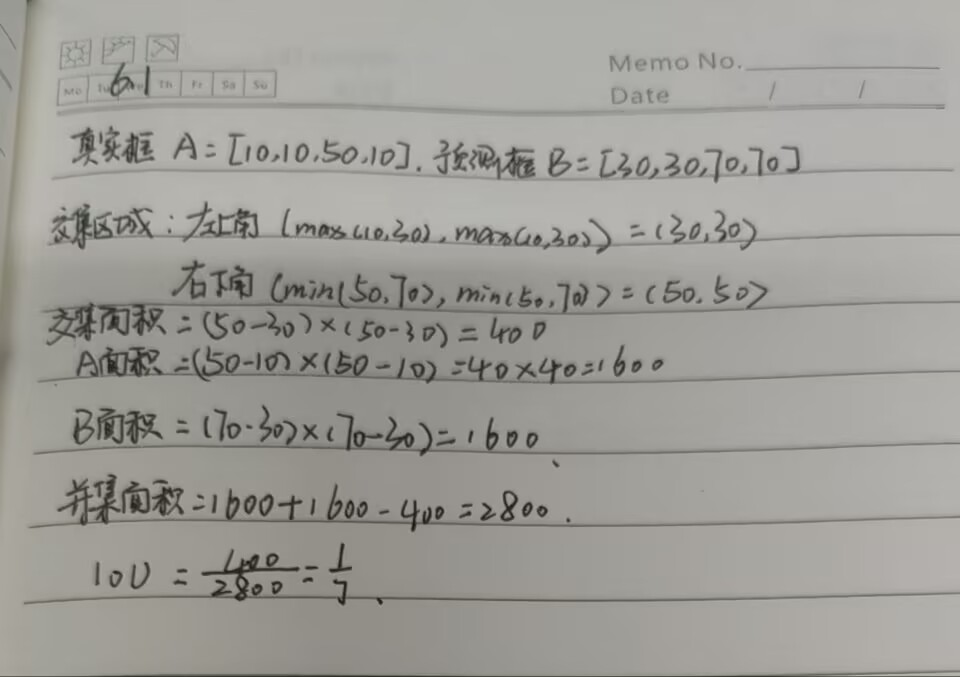
 6.2 标签平滑交叉熵损失

原理：将 one-hot 标签替换为软标签，避免模型对预测过于自信。

硬标签 one-hot：q_hard(k) = delta_{k,y} （当 k=y 时为1，否则0）

软标签（平滑后）：
q_smooth(k) = 1 - epsilon, 如果 k = y
= epsilon/(K-1), 否则

交叉熵损失：
L = - sum_{k=1}^{K} q_smooth(k) * log(p_k)
其中 p_k = softmax(logits)_k，K 为类别数，epsilon 为平滑因子（如 0.1）。

实际计算：直接计算 -log(p_y) 的加权和，或使用 log_softmax 后与平滑标签矩阵点乘。



In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LabelSmoothingCE(nn.Module):
    """标签平滑版的交叉熵损失"""
    def __init__(self, smoothing=0.1):
        super(LabelSmoothingCE,self).__init__()
        self.smoothing = smoothing

    def forward(self,pred,target):
        # pred: 模型输出的logits, shape (N, C)
        # target: 真实类别索引, shape (N,)
        N, C = pred.shape
        log_probs = F.log_softmax(pred,dim=1)

        # 构造平滑后的标签分布
        with torch.no_grad():
            # 初始全是 epsilon/(C-1)
            true_dist = torch.zeros_like(log_probs)
            true_dist.fill_(self.smoothing/(C-1))
            # 给正确类别的位置加上 1-epsilon
            true_dist.scatter_(1,target.unsqueeze(1),1.0-self.smoothing)

        # 计算损失
        loss = (-true_dist*log_probs).sum(dim=1).mean()
        return loss

# 快速测试
if __name__ == "__main__":
    criterion=LabelSmoothingCE(smoothing=0.1)
    logits=torch.randn(4,10)
    labels=torch.tensor([1,3,5,7])
    loss_val= criterion(logits,labels)
    print("损失值:",loss_val.item())

损失值: 2.472687244415283
